# Парная линейная регрессия

# Задания для самостоятельного выполнения
#### 1. Проверьте работу модели с разными начальными значениями параметров. Убедитесь, что модель всегда сходится к оптимуму.

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']
x.head()

0    1.462108
1    1.133769
2   -2.301539
3    1.744812
4    0.042214
Name: 0, dtype: float64

In [115]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self, b0=0.0, b1=0.0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, x):
        return self.b0 + self.b1 * x

    def error(self, x, y):
        return np.sum((self.predict(x) - y) ** 2) / (2 * len(x))

    def fit(self, x, y, alpha=0.01, max_steps=1000):
        for _ in range(max_steps):
            dJ0 = np.sum(self.predict(x) - y) / len(x)
            dJ1 = np.sum((self.predict(x) - y) * x) / len(x)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

In [116]:
# hyp = Model()
# steps, errors = hyp.fit(x, y)
# J = hyp.error(x, y)
# print("error after gradient descent:", J)

In [117]:
initial_values = [
    (0, 0),
    (5, -5),
    (-50, 50),
    (111, 111)
]

for b0, b1 in initial_values:
    model = Model(b0=b0, b1=b1)
    model.fit(x, y, alpha=0.01)
    print(f"({b0},{b1}) => b0={model.b0:.4f}, b1={model.b1:.4f}, Error={model.error(x,y):.6f}")

(0,0) => b0=-0.0021, b1=69.1866, Error=0.000003
(5,-5) => b0=-0.0019, b1=69.1867, Error=0.000002
(-50,50) => b0=-0.0039, b1=69.1859, Error=0.000009
(111,111) => b0=0.0086, b1=69.1917, Error=0.000042


#### 2. Проверьте работу модели с другими значениями скорости обучения. Найдите значение, при котором градиентный спуск расходится.

In [118]:
alphas = [0.001, 0.02, 0.1, 0.5, 1.0, 2.0]

for a in alphas:
    model = Model()
    model.fit(x, y, alpha=a)
    print(f"alpha={a}, error={model.error(x,y):.6f}")

alpha=0.001, error=253.134294
alpha=0.02, error=0.000000
alpha=0.1, error=0.000000
alpha=0.5, error=0.000000
alpha=1.0, error=0.000000
alpha=2.0, error=inf


#### 3. Модифицируйте код модели таким образом, чтобы он корректно работал как с Series, так и с DataFrame. При этом, конечно, датафрейм не должен содержать "лишних" столбцов.

In [119]:
class Model(object):
    def __init__(self, b0=0.0, b1=0.0):
        self.b0 = b0
        self.b1 = b1

    def to_series(self, data):
        if isinstance(data, pd.DataFrame):
            if data.shape[1] != 1:
                raise ValueError("must be one column")
            return data.iloc[:, 0]
        elif isinstance(data, pd.Series):
            return data
        else:
            return pd.Series(data)

    def predict(self, X):
        X = self.to_series(X)
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = self.to_series(X)
        Y = self.to_series(Y)
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.01, max_steps=1000):
        X = self.to_series(X)
        Y = self.to_series(Y)

        for _ in range(max_steps):
            dJ0 = np.sum(self.predict(X) - Y) / len(X)
            dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

# model = Model()
# model.fit(x.to_frame(), y.to_frame())
# print(f"b0 = {model.b0}, b1 = {model.b1}")

model_series = Model()
model_series.fit(x, y)
print("Series")
print(f"b0 = {model_series.b0}")
print(f"b1 = {model_series.b1}")

model_dataframe = Model()
model_dataframe.fit(x.to_frame(), y.to_frame())
print("DataFrame")
print(f"b0 = {model_dataframe.b0}")
print(f"b1 = {model_dataframe.b1}")

print(model_series.b0 - model_dataframe.b0)
print(model_series.b1 - model_dataframe.b1)

Series
b0 = -0.0020551424872833866
b1 = 69.18660207362986
DataFrame
b0 = -0.0020551424872833866
b1 = 69.18660207362986
0.0
0.0


#### 4. Модифицируйте алгоритм градиентного спука таким образом, чтобы он останавливаля, если ошибка перестает снижаться. Для этого сравнивайте, на сколько понизилась ошибка на каждом шаге и если это снижение меньше некоторой заранее заданной очень маленькой величины - выходите из цикла. Эту величину можно взять одну миллионную, например.

In [120]:
class Model(object):
    def __init__(self, b0=0.0, b1=0.0):
        self.b0 = b0
        self.b1 = b1

    def to_series(self, data):
        if isinstance(data, pd.DataFrame):
            if data.shape[1] != 1:
                raise ValueError("must be one column")
            return data.iloc[:, 0]
        elif isinstance(data, pd.Series):
            return data
        else:
            return pd.Series(data)

    def predict(self, X):
        X = self.to_series(X)
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = self.to_series(X)
        Y = self.to_series(Y)
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.01, tol=1e-6, max_steps=5000):
        X = self.to_series(X)
        Y = self.to_series(Y)
        prev_error = self.error(X, Y)

        for step in range(max_steps):
            dJ0 = np.sum(self.predict(X) - Y) / len(X)
            dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            new_error = self.error(X, Y)

            if abs(prev_error - new_error) < tol:
                print(f"stopped at step {step+1}")
                return step + 1

            prev_error = new_error
            
        print("stopped because max_steps reached")
        return max_steps

model = Model()
steps_used = model.fit(x, y)
print("b0 =", model.b0)
print("b1 =", model.b1)

stopped at step 841
b0 = -0.00899559445797967
b1 = 69.18229501224508


#### 5. Убедитесь, что алгоритм градиентного спуска завершается всегда - либо если ошибка перестает существенно меняться, либо при достижении максимального количества шагов.

In [121]:
# Да, алгоритм завершается

#### 6. Реализуйте механизм адаптивной скорости обучения. Чтобы не задавать вручную параметр alpha можно отслеживать, увеличивается ли ошибка после первого шага градиентного спуска. В начале задаем скорость обучения близкой к 1. Если ошибка после одного шага увеличивается - скорость обучения надо уменьшить (например, в 2 раза). Если не увеличивается - скорость обучения можно не трогать. Еще подумайте, как после уменьшения скорости перезапускать градиентный спуск заново.

In [122]:
def fit(self, X, Y, alpha=1.0, tol=1e-6, max_steps=5000):
    X = self._to_series(X)
    Y = self._to_series(Y)
    prev_error = self.error(X, Y)

    for step in range(max_steps):
        old_b0 = self.b0
        old_b1 = self.b1
        dJ0 = np.sum(self.predict(X) - Y) / len(X)
        dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
        self.b0 -= alpha * dJ0
        self.b1 -= alpha * dJ1
        new_error = self.error(X, Y)

        if new_error > prev_error:
            alpha /= 2
            self.b0 = old_b0
            self.b1 = old_b1
            continue

        if abs(prev_error - new_error) < tol:
            print(f"stopped at step {step+1}")
            break

        prev_error = new_error

#### 7. Добавьте к классу модели метод рисования графиков. Сделайте так, чтобы он был независим от масштаба переданных данных.

stopped at step 841


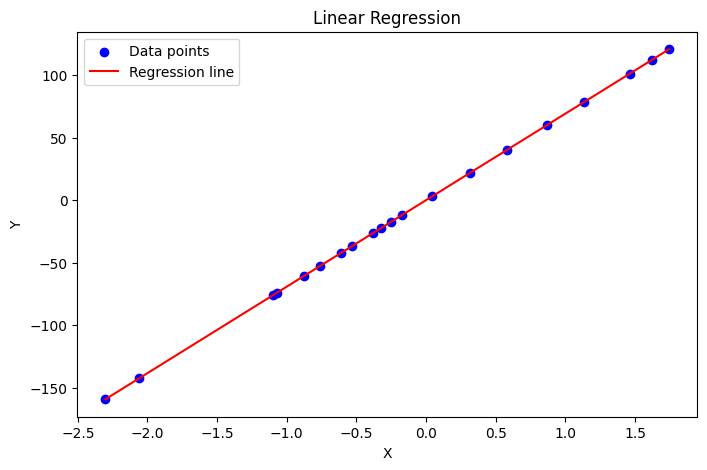

In [123]:
class Model:
    def __init__(self, b0=0.0, b1=0.0):
        self.b0 = b0
        self.b1 = b1

    def to_series(self, data):
        if isinstance(data, pd.DataFrame):
            if data.shape[1] != 1:
                raise ValueError("must be one column")
            return data.iloc[:, 0]
        elif isinstance(data, pd.Series):
            return data
        else:
            return pd.Series(data)

    def predict(self, X):
        X = self.to_series(X)
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = self.to_series(X)
        Y = self.to_series(Y)
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.01, tol=1e-6, max_steps=5000):
        X = self.to_series(X)
        Y = self.to_series(Y)
        prev_error = self.error(X, Y)

        for step in range(max_steps):
            old_b0 = self.b0
            old_b1 = self.b1
            dJ0 = np.sum(self.predict(X) - Y) / len(X)
            dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            new_error = self.error(X, Y)

            if new_error > prev_error:
                alpha /= 2
                self.b0 = old_b0
                self.b1 = old_b1
                continue

            if abs(prev_error - new_error) < tol:
                print(f"stopped at step {step+1}")
                break

            prev_error = new_error

    def plot(self, X, Y):
        X = self.to_series(X)
        Y = self.to_series(Y)

        X_line = np.linspace(X.min(), X.max(), 100)
        Y_line = self.predict(X_line)

        plt.figure(figsize=(8,5))
        plt.scatter(X, Y, color='blue', label='Data points')
        plt.plot(X_line, Y_line, color='red', label='Regression line')
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Linear Regression")
        plt.legend()
        plt.show()

model = Model()
model.fit(x, y, alpha=0.01, max_steps=1000)
model.plot(x, y)